In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load evaluation summaries
model_label_mapping = {
    # "contrastive-colbert-bclavie10m": "colbert-mine",
    # "contrastive-xtr-bclavie-kprime-1024": "xtr-mine",
    # "robro612/xtr-base-en-pylate": "xtr-google",
    # "experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k" : "xtr-primeqa",
    "experiment_1_contrastive_xtr_primeqa_kprime_64_bs196_50k_bugfix" : "xtr-kprime-64",
    "experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k_bugfix" : "xtr-kprime-128",
    "experiment_1_contrastive_xtr_primeqa_kprime_256_bs196_50k_bugfix" : "xtr-kprime-256",
    "experiment_1_contrastive_xtr_primeqa_kprime_512_bs196_50k_bugfix" : "xtr-kprime-512",
    # "experiment_1_contrastive_xtr_primeqa_kprime_128_bs196_50k" : "xtr-primeqa (bugged)",
    "experiment_1_contrastive_colbert_bs196_50k" : "colbert",
}

records = []
for path in Path("results_runs").glob("**/*evaluation.json"):
    data = json.loads(path.read_text())
    model = data.get("model", "")
    model_label = None
    for contains, label in model_label_mapping.items():
        if contains in model:
            model_label = label
            break
    if model_label is None:
        continue
        model_label = Path(model).name or model

    records.append(
        {
            "dataset": data.get("dataset"),
            "model_label": model_label,
            "model_name": "/".join(model.split("/")[-2:]),
            "retrieval_mode": data.get("retrieval_mode"),
            "k_token": data.get("k_token"),
            "retrieval_time": data.get("retrieve_time"),
            "imputation_mode" : data.get("imputation_mode", {}).get("mode", "min"),
            **data.get("evaluation_scores", {}),
        }
    )

In [3]:
df = pd.DataFrame(records).dropna(subset=["k_token", "retrieval_mode"]).sort_values(["dataset", "model_label", "retrieval_mode", "k_token"]).query("imputation_mode == 'min'")
# Take the max score for each dataset, model_name, k_token combination
df = df.groupby(['dataset', 'model_label', 'k_token', 'retrieval_mode']).max().reset_index()

df

,dataset,model_label,k_token,retrieval_mode,model_name,retrieval_time,imputation_mode,map,ndcg@10,ndcg@100,recall@10,recall@100,hit_rate@5
0,beir/fiqa/test,colbert,1000,XTR,experiment_1_contrastive_colbert_bs196_50k/che...,104.991697,min,0.301428,0.358706,0.418544,0.420058,0.644955,0.550926
1,beir/fiqa/test,colbert,4000,ColBERT,experiment_1_contrastive_colbert_bs196_50k/final,374.625289,min,0.312545,0.371476,0.430243,0.434815,0.655998,0.567901
2,beir/fiqa/test,colbert,10000,XTR,experiment_1_contrastive_colbert_bs196_50k/final,266.941903,min,0.307748,0.368740,0.426886,0.438137,0.659230,0.570988
3,beir/fiqa/test,colbert,40000,XTR,experiment_1_contrastive_colbert_bs196_50k/final,1144.461708,min,0.307924,0.368356,0.427517,0.437374,0.658396,0.566358
4,beir/fiqa/test,xtr-kprime-128,4000,XTR,experiment_1_contrastive_xtr_primeqa_kprime_12...,153.716466,min,0.286801,0.339453,0.403505,0.398737,0.637936,0.527778
...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,lotte/lifestyle/dev/search,colbert,4000,ColBERT,experiment_1_contrastive_colbert_bs196_50k/che...,820.652126,min,0.419926,0.493227,0.555928,0.535699,0.745777,0.741007
148,lotte/lifestyle/dev/search,colbert,10000,XTR,experiment_1_contrastive_colbert_bs196_50k/final,306.289559,min,0.416632,0.491431,0.552126,0.537944,0.740326,0.741007
149,lotte/lifestyle/dev/search,colbert,40000,XTR,experiment_1_contrastive_colbert_bs196_50k/final,818.908449,min,0.417877,0.493003,0.554976,0.539666,0.751833,0.745803
150,lotte/lifestyle/dev/search,xtr-kprime-128,10000,XTR,experiment_1_contrastive_xtr_primeqa_kprime_12...,249.713364,min,0.397742,0.467283,0.535839,0.518521,0.749789,0.731415


/scratch/jobs/rjha/164503/ipykernel_3914048/4036622115.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_list = plt.cm.get_cmap("tab10", len(model_labels))


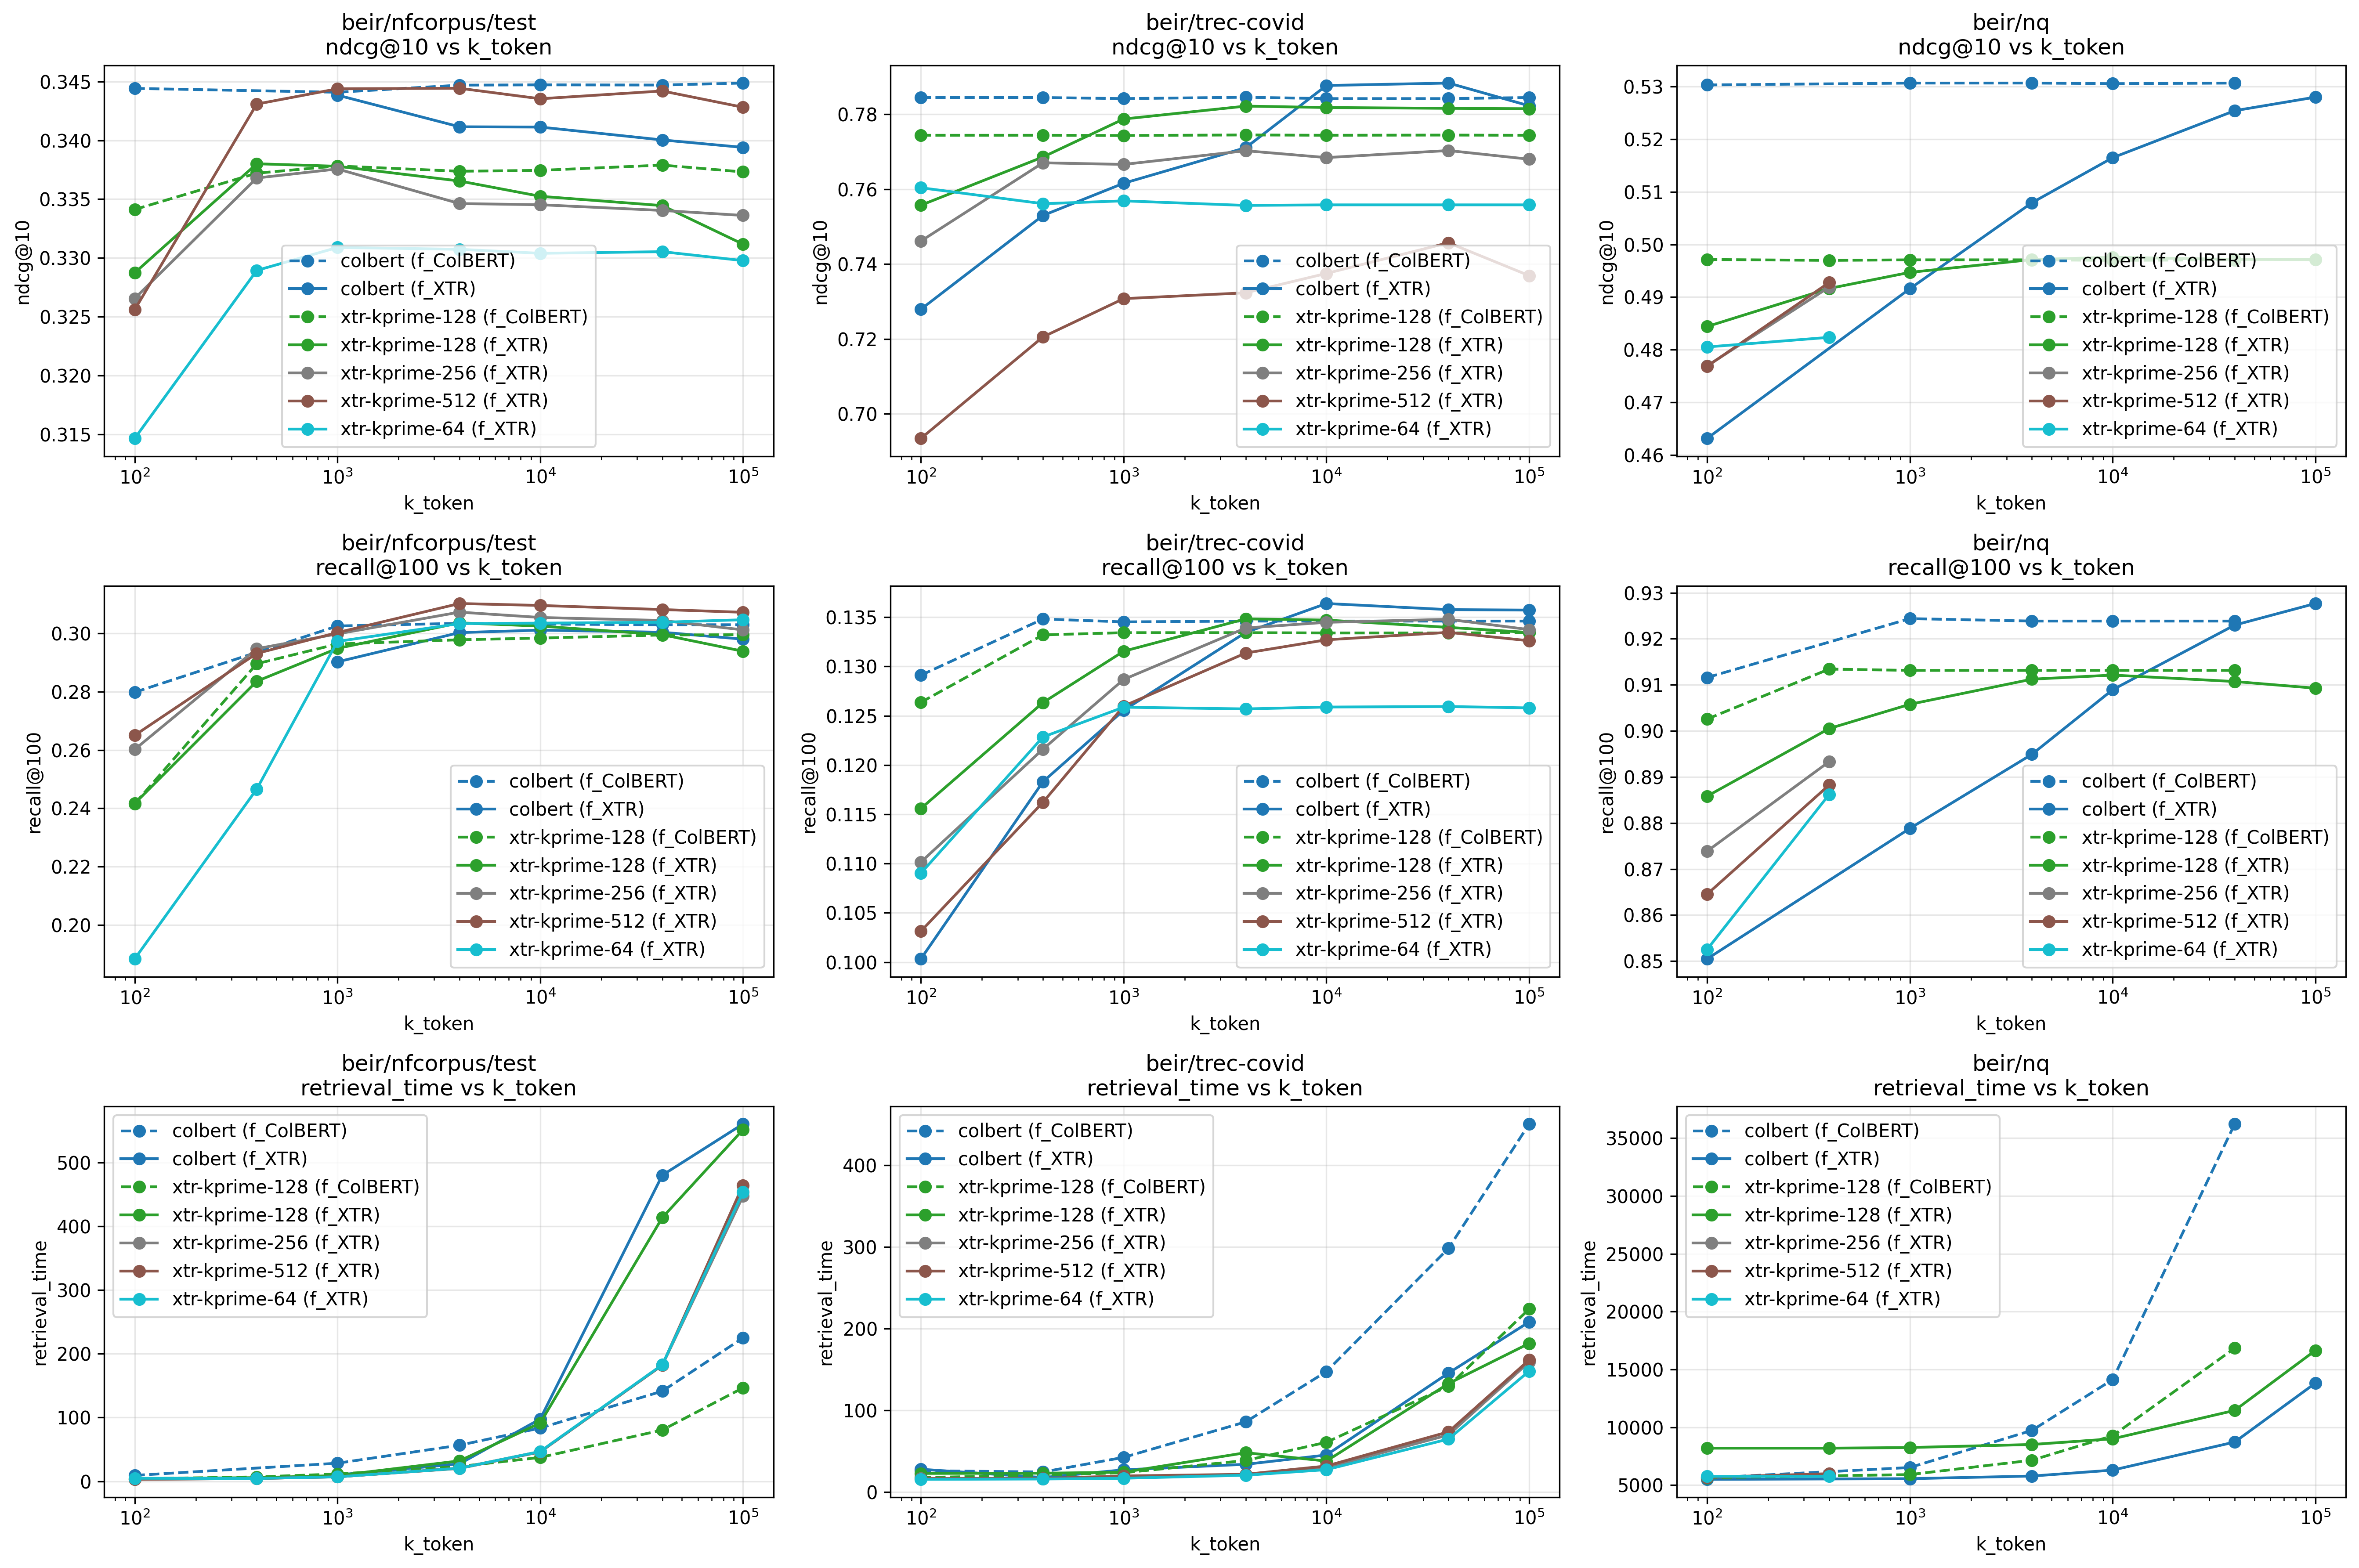


=== beir/nfcorpus/test : ndcg@10 ===
       model_label retrieval_mode  k_token   ndcg@10
8          colbert        ColBERT      100  0.344413
9          colbert        ColBERT     1000  0.344087
11         colbert        ColBERT     4000  0.344690
13         colbert        ColBERT    10000  0.344717
15         colbert        ColBERT    40000  0.344699
17         colbert        ColBERT   100000  0.344870
10         colbert            XTR     1000  0.343842
12         colbert            XTR     4000  0.341152
14         colbert            XTR    10000  0.341128
16         colbert            XTR    40000  0.340033
18         colbert            XTR   100000  0.339401
19  xtr-kprime-128        ColBERT      100  0.334124
21  xtr-kprime-128        ColBERT      400  0.337208
23  xtr-kprime-128        ColBERT     1000  0.337821
25  xtr-kprime-128        ColBERT     4000  0.337372
27  xtr-kprime-128        ColBERT    10000  0.337448
29  xtr-kprime-128        ColBERT    40000  0.337897
31  xtr-

In [4]:
# Multi-plot for all combinations of metrics and datasets

# Choose metrics and datasets to plot
import matplotlib.ticker as ticker
from itertools import cycle

metrics = ["ndcg@10", "recall@100", "retrieval_time"]  # add/remove metrics as desired
# metrics = ["recall@100"]
datasets = ["beir/nfcorpus/test", "beir/trec-covid", "beir/nq"]
# datasets = ["beir/trec-covid"]

n_metrics = len(metrics)
n_datasets = len(datasets)

fig, axes = plt.subplots(
    nrows=n_metrics, ncols=n_datasets, 
    figsize=(6 * n_datasets, 4 * n_metrics),
    squeeze=False,
    dpi=300,
)

# Choose colors for models
model_labels = df["model_label"].unique()
color_list = plt.cm.get_cmap("tab10", len(model_labels))
model2color = {label: color_list(i) for i, label in enumerate(model_labels)}

# Define the powers of 10 ticks and labels
x_ticks = [10**i for i in range(2, 6)]
x_tick_labels = [r"$10^{}$".format(i) for i in range(2, 6)]

# Linestyle mapping by retrieval mode
retrieval2style = {
    "ColBERT": "dashed",
    "XTR": "solid"
}

for i, metric in enumerate(metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i][j]
        df_filtered = df[df["dataset"] == dataset]
        
        for (model_label, retrieval_mode), group in df_filtered.groupby(["model_label", "retrieval_mode"]):
            group = group.sort_values("k_token")
            color = model2color.get(model_label, "black")
            linestyle = retrieval2style.get(retrieval_mode, "solid")
            ax.plot(
                group["k_token"],
                group[metric],
                marker="o",
                label=f"{model_label} (f_{retrieval_mode})",
                color=color,
                linestyle=linestyle,
            )
        
        ax.set_xscale("log")
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels)
        ax.set_xlabel("k_token")
        ax.set_ylabel(metric)
        ax.set_title(f"{dataset}\n{metric} vs k_token")
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quick table view for all (dataset, metric) pairs
for metric in metrics:
    for dataset in datasets:
        print(f"\n=== {dataset} : {metric} ===")
        print(
            df[df["dataset"] == dataset][
                ["model_label", "retrieval_mode", "k_token", metric]
            ].sort_values(["model_label", "retrieval_mode", "k_token"])
        )



In [ ]:
# ===============================================
# MATPLOTLIB VERSION - Paper-ready style
# ===============================================
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import colors as mcolors
import numpy as np
import re

# Use a clean style for papers
plt.style.use('seaborn-v0_8-paper')
# Increase font sizes for readability
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 13,
    'lines.linewidth': 2,
    'lines.markersize': 6,
})

metrics = ["ndcg@10", "recall@100", "retrieval_time"]
datasets = ["beir/nfcorpus/test", "beir/trec-covid", "beir/nq"]

n_metrics = len(metrics)
n_datasets = len(datasets)

fig, axes = plt.subplots(
    nrows=n_metrics, ncols=n_datasets,
    figsize=(5 * n_datasets, 3.5 * n_metrics),
    squeeze=False,
    dpi=150,
    sharex=False,  # Each plot gets its own x-axis scale
    sharey=False,  # Each plot gets its own y-axis scale
)

# Filter data: ColBERT only shows f_ColBERT (retrieval_mode == "ColBERT")
# XTR models show f_XTR (retrieval_mode == "XTR")
df_plot = df.copy()
df_plot = df_plot[
    ((df_plot["model_label"] == "colbert") & (df_plot["retrieval_mode"] == "ColBERT")) |
    ((df_plot["model_label"] != "colbert") & (df_plot["retrieval_mode"] == "XTR"))
]

# Color scheme: Blue for ColBERT, shades of orange (complementary) for XTR variants
colbert_color = "#2E86AB"  # Blue

# Get XTR models and extract k_prime values for sorting
xtr_models_unsorted = [m for m in df_plot["model_label"].unique() if m != "colbert"]

# Extract k_prime value from model name and sort by it
def extract_kprime(model_name):
    """Extract k_prime value from model name like 'xtr-kprime-128'"""
    match = re.search(r'kprime[_-](\d+)', model_name)
    if match:
        return int(match.group(1))
    return 0  # default for models without kprime in name

xtr_models = sorted(xtr_models_unsorted, key=extract_kprime)

# Create shades of orange for XTR models (from light to dark)
# Using orange as complementary to blue
if len(xtr_models) > 0:
    # Create a gradient from light orange to dark orange/red
    base_hue = 25 / 360  # Orange hue
    sat_values = np.linspace(0.5, 0.9, len(xtr_models))
    val_values = np.linspace(0.95, 0.65, len(xtr_models))

    xtr_colors = []
    for s, v in zip(sat_values, val_values):
        rgb = mcolors.hsv_to_rgb([base_hue, s, v])
        xtr_colors.append(rgb)

    xtr_model2color = {model: color for model, color in zip(xtr_models, xtr_colors)}
else:
    xtr_model2color = {}

model2color = {"colbert": colbert_color, **xtr_model2color}

# Define the powers of 10 ticks and labels
x_ticks = [10**i for i in range(2, 6)]
x_tick_labels = [r"$10^{}$".format(i) for i in range(2, 6)]

for i, metric in enumerate(metrics):
    for j, dataset in enumerate(datasets):
        ax = axes[i][j]
        df_filtered = df_plot[df_plot["dataset"] == dataset]

        # Plot in order: ColBERT first, then XTR models sorted by k_prime
        plot_order = ["colbert"] + xtr_models
        for model_label in plot_order:
            group = df_filtered[df_filtered["model_label"] == model_label].sort_values("k_token")
            if len(group) == 0:
                continue
                
            color = model2color.get(model_label, "black")

            # Label format
            if model_label == "colbert":
                label = "ColBERT (f_ColBERT)"
            else:
                label = f"{model_label} (f_XTR)"

            ax.plot(
                group["k_token"],
                group[metric],
                marker="o",
                label=label,
                color=color,
                linewidth=2,
                markersize=6,
            )

        ax.set_xscale("log")
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_tick_labels)
        ax.set_xlabel("$k_{token}$", fontsize=11)
        ax.set_ylabel(metric.replace("@", "@"), fontsize=11)

        # Extract dataset name (second element in path like "beir/nfcorpus/test" -> "nfcorpus")
        parts = dataset.split("/")
        dataset_short = parts[1] if len(parts) > 1 else dataset
        ax.set_title(f"{dataset_short}", fontsize=12, pad=10)

        # Only show legend in top-right plot of each row
        if j == n_datasets - 1:
            ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), frameon=True, fancybox=False, shadow=False)

        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig6_matplotlib.png", dpi=300, bbox_inches='tight')
plt.savefig("figures/fig6_matplotlib.pdf", bbox_inches='tight')
plt.show()

print("Matplotlib version saved to figures/fig6_matplotlib.{png,pdf}")
print(f"XTR models sorted by k_prime: {xtr_models}")

In [ ]:
# ===============================================
# PLOTNINE VERSION (ggplot2-style)
# ===============================================
try:
    from plotnine import *
    import numpy as np
    import re

    metrics = ["ndcg@10", "recall@100", "retrieval_time"]
    datasets = ["beir/nfcorpus/test", "beir/trec-covid", "beir/nq"]

    # Filter data: ColBERT only shows f_ColBERT, XTR models show f_XTR
    df_plot = df.copy()
    df_plot = df_plot[
        ((df_plot["model_label"] == "colbert") & (df_plot["retrieval_mode"] == "ColBERT")) |
        ((df_plot["model_label"] != "colbert") & (df_plot["retrieval_mode"] == "XTR"))
    ]

    # Extract k_prime value from model name and sort by it
    def extract_kprime(model_name):
        """Extract k_prime value from model name like 'xtr-kprime-128'"""
        match = re.search(r'kprime[_-](\d+)', model_name)
        if match:
            return int(match.group(1))
        return 0  # default for models without kprime in name

    # Get XTR models sorted by k_prime value
    xtr_models_unsorted = [m for m in df_plot["model_label"].unique() if m != "colbert"]
    xtr_models = sorted(xtr_models_unsorted, key=extract_kprime)

    # Add formatted labels
    df_plot["model_display"] = df_plot.apply(
        lambda row: "ColBERT (f_ColBERT)" if row["model_label"] == "colbert" else f"{row['model_label']} (f_XTR)",
        axis=1
    )

    # Color scheme matching matplotlib version
    colbert_color = "#2E86AB"

    # Create shades of orange for XTR
    from matplotlib import colors as mcolors
    if len(xtr_models) > 0:
        base_hue = 25 / 360
        sat_values = np.linspace(0.5, 0.9, len(xtr_models))
        val_values = np.linspace(0.95, 0.65, len(xtr_models))

        xtr_colors = []
        for s, v in zip(sat_values, val_values):
            rgb = mcolors.hsv_to_rgb([base_hue, s, v])
            xtr_colors.append(mcolors.rgb2hex(rgb))

        xtr_model2color = {model: color for model, color in zip(xtr_models, xtr_colors)}
    else:
        xtr_model2color = {}

    # Create color mapping for display labels
    color_mapping = {}
    for label in df_plot["model_label"].unique():
        if label == "colbert":
            color_mapping["ColBERT (f_ColBERT)"] = colbert_color
        else:
            color_mapping[f"{label} (f_XTR)"] = xtr_model2color.get(label, "#E07A5F")

    # Set factor levels for proper ordering in legend (ColBERT first, then XTR by k_prime)
    display_order = ["ColBERT (f_ColBERT)"] + [f"{m} (f_XTR)" for m in xtr_models]
    df_plot["model_display"] = pd.Categorical(df_plot["model_display"], categories=display_order, ordered=True)

    # Create faceted plot for each metric
    for metric in metrics:
        df_metric = df_plot[df_plot["dataset"].isin(datasets)].copy()

        # Create short dataset names (second element: "beir/nfcorpus/test" -> "nfcorpus")
        df_metric["dataset_short"] = df_metric["dataset"].apply(
            lambda x: x.split("/")[1] if "/" in x and len(x.split("/")) > 1 else x
        )

        p = (
            ggplot(df_metric, aes(x="k_token", y=metric, color="model_display", group="model_display"))
            + geom_line(size=1.2)
            + geom_point(size=3)
            + scale_x_log10(
                breaks=[10**i for i in range(2, 6)],
                labels=[f"$10^{i}$" for i in range(2, 6)]
            )
            + scale_color_manual(values=color_mapping)
            + facet_wrap("~ dataset_short", nrow=1, scales="free_y")  # Independent y-axis scales
            + labs(
                x="$k_{token}$",
                y=metric.replace("@", "@"),
                color="Model"
            )
            + theme_minimal()
            + theme(
                figure_size=(15, 4),
                text=element_text(size=11),
                axis_title=element_text(size=12),
                plot_title=element_text(size=13, face="bold"),
                legend_position="right",
                legend_title=element_text(size=11),
                legend_text=element_text(size=10),
                panel_grid_major=element_line(alpha=0.3, linetype="dashed"),
                panel_grid_minor=element_blank(),
                strip_text=element_text(size=11, face="bold"),
            )
        )

        # Save each metric as a separate figure
        metric_safe = metric.replace("@", "_at_").replace("/", "_")
        p.save(f"figures/fig6_plotnine_{metric_safe}.png", dpi=300, width=15, height=4)
        p.save(f"figures/fig6_plotnine_{metric_safe}.pdf", width=15, height=4)
        print(f"Plotnine version for {metric} saved to figures/fig6_plotnine_{metric_safe}.{{png,pdf}}")

        print(p)

    print(f"XTR models sorted by k_prime: {xtr_models}")

except ImportError:
    print("plotnine not installed. Install with: pip install plotnine")